# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

[Unlabeled] 300 images from /kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024/archive/val/val


/tmp/ipykernel_40/3835714030.py:136: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  markerline, stemlines, baseline = ax0.stem(


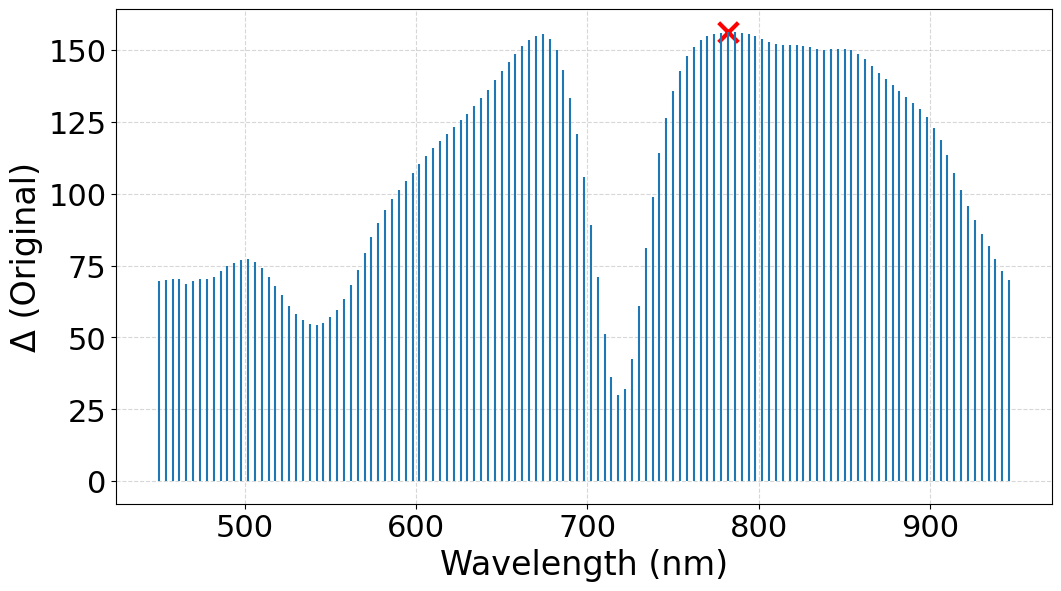

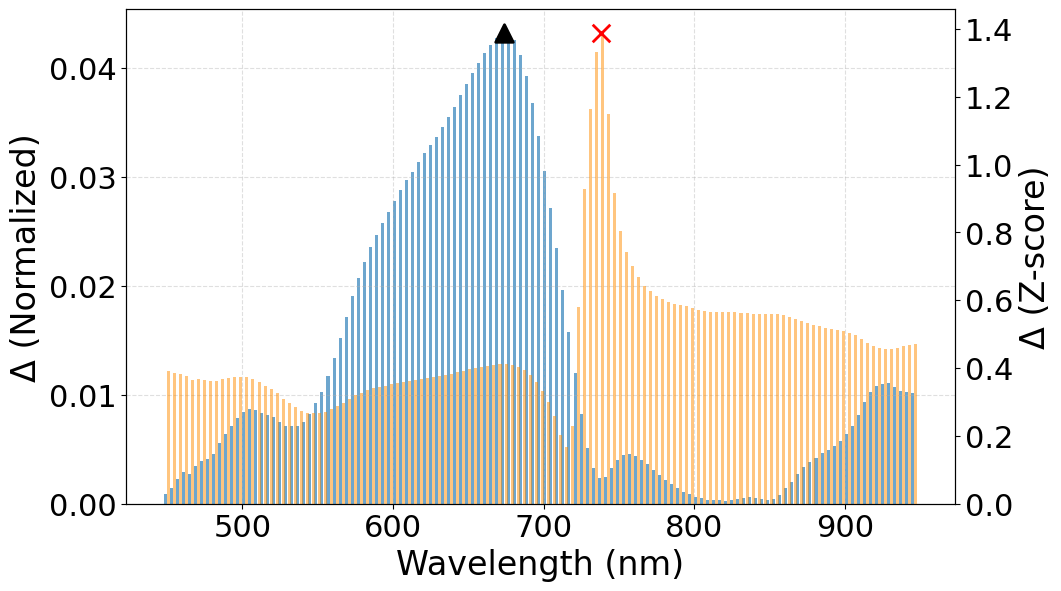

In [1]:
# Cell 1: Imports, environment setup, and dataset indexing / 라이브러리, 환경 설정, 데이터셋 인덱싱
import os, copy, math, random, warnings, time, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage import io
from skimage.transform import resize as sk_resize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix,  recall_score, cohen_kappa_score
import torch
import torch.nn as nn
import torch.nn.functional as F           
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
import re
from torch.utils.data import Sampler
from math import sqrt
from sklearn.manifold import TSNE
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from matplotlib import cm

from IPython.display import display
import math


warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# ────────────────────────────── 2. 경로 및 클래스 설정 ──────────────────────────────
BASE_DIR_HSI = "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024"
TRAIN_DIR_HSI = os.path.join(BASE_DIR_HSI, "archive/train")

# Already NDVI-cleaned split CSVs / 이미 NDVI 필터링이 끝난 clean split CSV
TRAIN_CSV = "/kaggle/input/datasets/silverbullet99/kkkkkk/train_full_df_clean.csv"
TEST_CSV  = "/kaggle/input/datasets/silverbullet99/kkkkkk/test_hold_df_clean.csv"

CLASSES_HSI = ["Health", "Other", "Rust"]
WAVELENGTHS      = np.arange(450, 950, 4)

# ────────────────────────────── 2-추가. 언라벨드 데이터 경로 ──────────────────────────────
UNLABELED_DIR_HSI = "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024/archive/val/val"
UNLABELED_EXTS = (".tif", ".tiff")

# ────────────────────────────── 3-추가. 언라벨드 DF 헬퍼 ──────────────────────────────
def create_unlabeled_dataframe(base_dir, file_exts=UNLABELED_EXTS):
    records = []
    if os.path.isdir(base_dir):
        for f in os.listdir(base_dir):
            if f.lower().endswith(file_exts):
                records.append({"path": os.path.join(base_dir, f)})
    return pd.DataFrame(records)

# ────────────────────────────── 4-추가. 언라벨드 DF 로딩 ──────────────────────────────
unlabeled_df = create_unlabeled_dataframe(UNLABELED_DIR_HSI)
print(f"[Unlabeled] {len(unlabeled_df)} images from {UNLABELED_DIR_HSI}")


# ────────────────────────────── 3. 헬퍼 함수 정의 ──────────────────────────────
def load_hsi(path, wavelengths=WAVELENGTHS):
    arr = io.imread(path).astype(np.float32)
    assert arr.ndim == 3, f"Unexpected HSI shape: {arr.shape}"
    band_axis = int(np.argmin([abs(s - len(wavelengths)) for s in arr.shape]))
    return np.moveaxis(arr, band_axis, -1)

def create_dataframe(base_dir, classes, file_exts, class_map=None):
    records = []
    for cls in (class_map.keys() if class_map else classes):
        d = os.path.join(base_dir, cls)
        if os.path.isdir(d):
            for f in os.listdir(d):
                if f.lower().endswith(file_exts):
                    label = class_map.get(cls, cls) if class_map else cls
                    records.append({"label": label, "path": os.path.join(d, f)})
    return pd.DataFrame(records)

def compute_hsi_mean_spectra_full(df, classes):
    spectra_o = {c: [] for c in classes}
    min_len = float("inf")
    for cls in classes:
        for p in df[df.label == cls].path:
            v = load_hsi(p).mean(axis=(0, 1))
            spectra_o[cls].append(v)
            min_len = min(min_len, len(v))
    wl_axis = WAVELENGTHS[:min_len]
    avg_o = {c: np.vstack([v[:min_len] for v in spectra_o[c]]).mean(axis=0) if spectra_o[c] else np.zeros(min_len) for c in classes}
    return avg_o, wl_axis

def safe_norm(v):
    v = np.nan_to_num(v)
    mn, mx = v.min(), v.max()
    return np.zeros_like(v) if mx == mn else (v - mn) / (mx - mn)

def moving_avg(x, k=5):
    k = max(3, k | 1)
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode='edge')
    return np.convolve(xp, np.ones(k) / k, mode='valid')

# ────────────────────────────── 4. 데이터 로딩 및 스펙트럼 계산 ──────────────────────────────
hsi_df = create_dataframe(TRAIN_DIR_HSI, CLASSES_HSI, (".tif",))

avg_hsi_o, wl_axis = compute_hsi_mean_spectra_full(hsi_df, CLASSES_HSI)
avg_hsi_n = {c: safe_norm(avg_hsi_o[c]) for c in CLASSES_HSI}
mu_all = np.stack(list(avg_hsi_o.values())).mean(axis=0)
sd_all = np.stack(list(avg_hsi_o.values())).std(axis=0) + 1e-8
avg_hsi_z = {c: (avg_hsi_o[c] - mu_all) / sd_all for c in avg_hsi_o}

# ────────────────────────────── 5. 스펙트럼 차이 계산 및 피크 탐지 ──────────────────────────────
delta_o_abs = np.abs(avg_hsi_o["Health"] - avg_hsi_o["Rust"])
delta_n_abs = np.abs(avg_hsi_n["Health"] - avg_hsi_n["Rust"])
delta_z_abs = np.abs(avg_hsi_z["Health"] - avg_hsi_z["Rust"])

d_o, d_n, d_z = moving_avg(delta_o_abs), moving_avg(delta_n_abs), moving_avg(delta_z_abs)
peak_idx_o, peak_idx_n, peak_idx_z = np.argmax(d_o), np.argmax(d_n), np.argmax(d_z)

# ────────────────────────────── 6. 시각화 (Discrete + 2 Figures) ──────────────────────────────

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
})

wl_axis_ma = wl_axis[:len(d_o)]

# =========================================================
# Figure 1: Original Scale (Discrete Stem Plot)
#  - 가로 줄임 + constrained_layout 사용
# =========================================================
fig, ax0 = plt.subplots(1, 1, figsize=(10.5, 5.8), constrained_layout=True)

markerline, stemlines, baseline = ax0.stem(
    wl_axis_ma, d_o,
    basefmt=" ", markerfmt=" ",
    use_line_collection=True,
)
markerline.set_visible(False)

ax0.scatter(
    wl_axis_ma[peak_idx_o], d_o[peak_idx_o],
    marker="x", c="red", s=200, linewidth=3
)

ax0.set_xlabel("Wavelength (nm)")
ax0.set_ylabel("Δ (Original)")
ax0.grid(ls="--", alpha=0.5)

plt.show()


# =========================================================
# Figure 2: Normalized vs Z-Score (Discrete Bars + Dual Y-Axis)
#  - 가로 줄임 + constrained_layout 사용
# =========================================================
fig, ax_left = plt.subplots(1, 1, figsize=(10.5, 5.8), constrained_layout=True)
ax_right = ax_left.twinx()

bar_w  = 2.0
offset = bar_w * 0.55

bars_n = ax_left.bar(
    wl_axis_ma - offset, d_n[:len(wl_axis_ma)],
    width=bar_w, align="center",
    alpha=0.65, edgecolor="none",
)

bars_z = ax_right.bar(
    wl_axis_ma + offset, d_z[:len(wl_axis_ma)],
    width=bar_w, align="center",
    alpha=0.50, edgecolor="none",
    color="darkorange",
)

ax_left.scatter(
    wl_axis_ma[peak_idx_n], d_n[peak_idx_n],
    marker="^", c="black", s=160, linewidth=2,
)

ax_right.scatter(
    wl_axis_ma[peak_idx_z], d_z[peak_idx_z],
    marker="x", c="red", s=160, linewidth=2,
)

ax_left.set_xlabel("Wavelength (nm)")
ax_left.set_ylabel("Δ (Normalized)")
ax_right.set_ylabel("Δ (Z-score)")

ax_left.grid(ls="--", alpha=0.4)

plt.show()




In [2]:
# Cell 2: Experiment configuration / 실험 설정
class CFG:
    # Basic settings / 기본 설정
    seed = 42
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Already NDVI-cleaned split CSVs / 이미 NDVI 필터링이 끝난 clean split CSV
    train_csv = "/kaggle/input/datasets/silverbullet99/kkkkkk/train_full_df_clean.csv"
    test_csv  = "/kaggle/input/datasets/silverbullet99/kkkkkk/test_hold_df_clean.csv"

    # Band-selection settings / 밴드 선택 설정
    prior_wavelengths = (531, 554, 570, 667, 700)
    adjcorr_threshold = 0.95
    stability_quantile = 0.25  # Bottom-quartile cutoff for stability score / 안정성 점수 하위 사분위 기준


    # Model/training settings / 모델 및 학습 설정
    n_folds = 5
    hsi_img_size   = 128          # Preprocessed HSI size for the 1D branch / 1D 브랜치 입력 크기
    rgb_input_size = 224          # [동일] ResNet-18 입력 크기
    hsi_epochs     = 50
    hsi_batch_size = 16
    hsi_wd         = 3e-4

    # 손실/라벨 스무딩
    hsi_ls = 0.02

    # C1: Discriminative LR (예전과 동일)
    lr_head = 2e-4 
    lr_l1l2 = 5e-6 
    lr_l3   = 1e-5 
    lr_l4   = 2e-5 

    # 스케줄러/얼리스탑
    reduce_patience = 5
    reduce_factor   = 0.5
    es_patience     = 8

    # 로깅/타이밍
    log_confusion_matrix = True
    measure_timing = True
    output_dir = "./output"
    model_dir  = os.path.join(output_dir, "models")
    os.makedirs(model_dir, exist_ok=True)

    # 증강 스위치 (모두 OFF 시작)
    use_2d_rrc         = False
    use_2d_jitter      = False
    use_1d_band_shift  = False
    use_1d_gauss_noise = False
    noise_sigma        = 0.006

    # Class-imbalance handling / 클래스 불균형 처리
    use_balanced_batches = True
    use_weighted_sampler = False
    use_focal_loss       = False
    focal_alpha          = [1.5, 1.0, 1.0]  # [Health, Other, Rust]
 
    # NDVI에 사용할 밴드(존재하지 않을 때는 근접 nm 자동 선택)
    ndvi_red_nm_list  = [658, 662, 666, 670, 674]   # mean(RED)
    ndvi_nir_primary  = [774, 778, 782, 786, 790] # 782



def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

set_seed(CFG.seed)



--- [밴드 선택] 2D 브랜치용 (3개 피크) ---
- 파장(nm): 674
- 파장(nm): 738
- 파장(nm): 782

--- [밴드 선택] 1D 브랜치용 (전체, 7개) ---
- 이름: OriginalBand_530nm, 유형: 원본 밴드, 파장(nm): [530]
- 이름: OriginalBand_554nm, 유형: 원본 밴드, 파장(nm): [554]
- 이름: OriginalBand_570nm, 유형: 원본 밴드, 파장(nm): [570]
- 이름: MeanBand_666nm, 유형: 평균화된 그룹, 파장(nm): [658, 662, 666, 670, 674]
- 이름: OriginalBand_698nm, 유형: 원본 밴드, 파장(nm): [698]
- 이름: OriginalBand_738nm, 유형: 원본 밴드, 파장(nm): [738]
- 이름: OriginalBand_782nm, 유형: 원본 밴드, 파장(nm): [782]


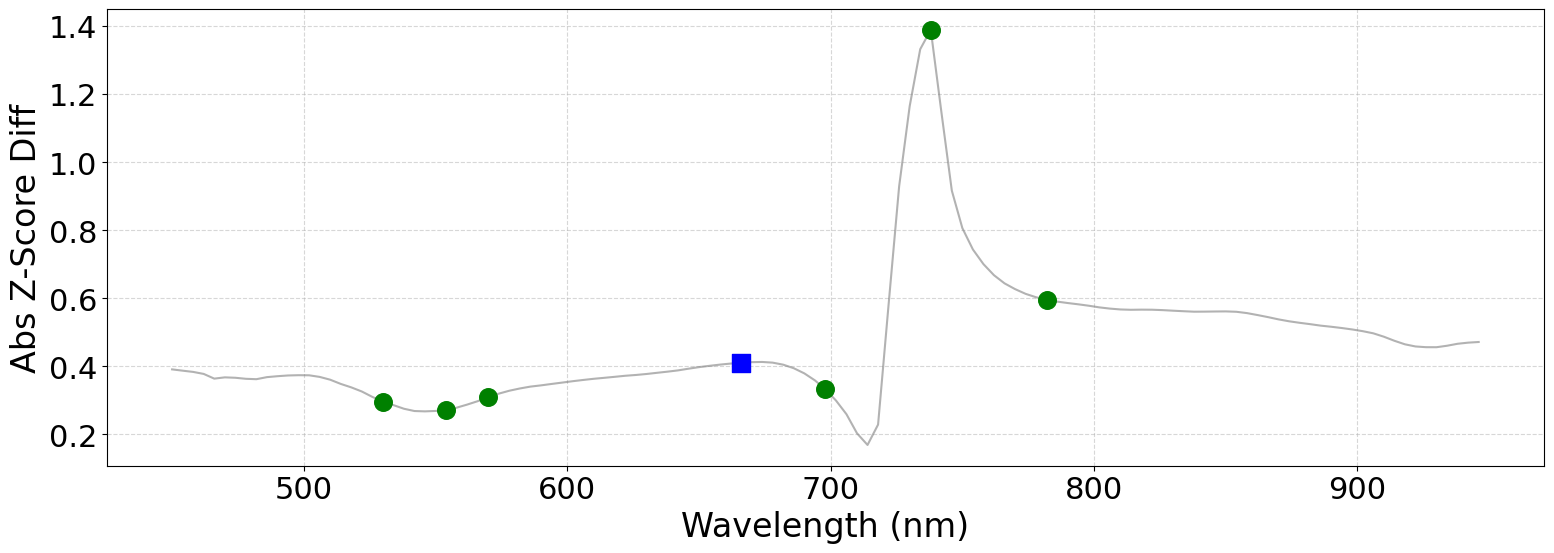

In [3]:
# Cell 3: Knowledge-guided and data-driven band-selection utilities / 지식 기반 및 데이터 기반 밴드 선택 유틸리티
# Utility functions / 유틸리티 함수

# def stratified_split(df, label_col='label', seed=42, train_ratio=0.7, val_ratio=0.15):
#     tr, tmp = train_test_split(df, test_size=1-train_ratio, stratify=df[label_col], random_state=seed)
#     val_rel_ratio = val_ratio / (1 - train_ratio)
#     va, te = train_test_split(tmp, test_size=1-val_rel_ratio, stratify=tmp[label_col], random_state=seed)
#     return tr.reset_index(drop=True), va.reset_index(drop=True), te.reset_index(drop=True)
    
def nearest_idx(wavelength_axis, target_nm):
    return int(np.argmin(np.abs(wavelength_axis - target_nm)))
    
def estimate_stability_and_adjcorr(df, wl_axis, max_imgs=500, seed=42):
    """Estimate per-band stability score and adjacent-band correlation.
    각 밴드의 안정성 점수와 인접 밴드 상관관계를 계산합니다.

    The score is defined as mean divided by standard deviation with epsilon.
    이 점수는 평균을 표준편차와 epsilon의 합으로 나눈 값입니다.
    """
    rng = np.random.RandomState(seed)
    paths = rng.choice(df['path'].tolist(), size=min(len(df), max_imgs), replace=False)
    M = np.vstack([load_hsi(p).mean(axis=(0, 1))[:len(wl_axis)] for p in paths])
    mu = M.mean(0)
    sd = M.std(0) + 1e-8
    stability_score = mu / sd
    B = M.shape[1]
    adj = np.zeros(B)
    for i in range(B - 1):
        ci = np.corrcoef(M[:, i], M[:, i + 1])[0, 1]
        adj[i] = 0.0 if np.isnan(ci) else ci
    if B > 1:
        adj[B - 1] = adj[B - 2]
    return stability_score, adj, M

def find_max_slope_bands(curve, n_bands):
    if len(curve) < 2: return []
    gradient = np.abs(np.gradient(curve))
    top_indices = np.argsort(gradient)[-n_bands:]
    return sorted(top_indices)

def select_bands_A_from_curves(avg_hsi_o, avg_hsi_n, avg_hsi_z, wl_axis, cfg):
    def moving_avg(x, k=5):
        k = max(3, k | 1); pad = k // 2
        xp = np.pad(x, (pad, pad), mode='edge')
        return np.convolve(xp, np.ones(k)/k, mode='valid')

    d_o = moving_avg(np.abs(avg_hsi_o["Health"] - avg_hsi_o["Rust"]))
    d_n = moving_avg(np.abs(avg_hsi_n["Health"] - avg_hsi_n["Rust"]))
    d_z = moving_avg(np.abs(avg_hsi_z["Health"] - avg_hsi_z["Rust"]))

    peak_indices_3 = sorted(list(set([np.argmax(d_o), np.argmax(d_n), np.argmax(d_z)])))
    bands_for_2d = [('PeakBand', [idx]) for idx in peak_indices_3]

    candidates = set(peak_indices_3) | set([nearest_idx(wl_axis, nm) for nm in CFG.prior_wavelengths])
    
    hsi_bin = hsi_df[hsi_df.label.isin(["Health", "Rust"])]
    stability_score, adj, M = estimate_stability_and_adjcorr(hsi_bin, wl_axis, seed=CFG.seed)
    stability_threshold = np.quantile(stability_score, CFG.stability_quantile)

    bands_for_1d, processed = [], set()
    for idx in sorted(list(candidates)):
        if idx in processed: continue
        is_low_stability = stability_score[idx] < stability_threshold
        group = {idx}
        # Expand to highly correlated neighbors within ±2 bands / ±2 범위의 고상관 인접 밴드로 확장
        left_idx = idx - 1
        while left_idx >= 0 and adj[left_idx] > CFG.adjcorr_threshold and (idx - left_idx) <= 2:
            group.add(left_idx); left_idx -= 1
        right_idx = idx
        while right_idx < len(adj)-1 and adj[right_idx] > CFG.adjcorr_threshold and (right_idx + 1 - idx) <= 2:
            group.add(right_idx + 1); right_idx += 1
        group = sorted(list(group))

        if is_low_stability and len(group) > 1:
            mean_band_pixels = M[:, group].mean(axis=1)
            stability_after = mean_band_pixels.mean() / (mean_band_pixels.std() + 1e-8)
            if stability_after > stability_score[idx]:
                band_name = f"MeanBand_{int(wl_axis[int(np.mean(group))])}nm"
                bands_for_1d.append((band_name, group)); processed.update(group)
            else:
                bands_for_1d.append((f"OriginalBand_{int(wl_axis[idx])}nm", [idx])); processed.add(idx)
        else:
            bands_for_1d.append((f"OriginalBand_{int(wl_axis[idx])}nm", [idx])); processed.add(idx)

    return bands_for_2d, bands_for_1d, d_z

# Run proposed band selection / 제안 밴드 선택 실행
bands_2d, bands_1d, final_d_z = select_bands_A_from_curves(avg_hsi_o, avg_hsi_n, avg_hsi_z, wl_axis, CFG)


print("--- [밴드 선택] 2D 브랜치용 (3개 피크) ---")
for name, indices in bands_2d:
    print(f"- 파장(nm): {int(wl_axis[indices[0]])}")

print(f"\n--- [밴드 선택] 1D 브랜치용 (전체, {len(bands_1d)}개) ---")
for name, indices in bands_1d:
    band_type = "평균화된 그룹" if "Mean" in name else "원본 밴드"
    wavelengths = [int(wl_axis[i]) for i in indices]
    print(f"- 이름: {name}, 유형: {band_type}, 파장(nm): {wavelengths}")

# Optional visualization / 선택적 시각화
fig, ax = plt.subplots(figsize=(16, 6))

# Increase default font size for publication-quality plots / 논문용 그림을 위해 기본 폰트 크기 조정
plt.rcParams.update({
    "font.size": 22,        # 기본
    "axes.labelsize": 24,   # x/y 라벨
    "xtick.labelsize": 22,  # x tick 숫자
    "ytick.labelsize": 22,  # y tick 숫자
})

# Difference curve / 차이 곡선
ax.plot(
    wl_axis,
    final_d_z,
    color="gray",
    alpha=0.6
)

mean_bands = [item for item in bands_1d if "Mean" in item[0]]
orig_bands = [item for item in bands_1d if "Original" in item[0]]

# Locally averaged bands / 국소 평균화 밴드
if mean_bands:
    mean_indices = [int(np.mean(item[1])) for item in mean_bands]
    ax.scatter(
        wl_axis[mean_indices],
        final_d_z[mean_indices],
        c="blue",
        marker="s",
        s=180,
        zorder=5
    )

# Original bands / 원본 밴드
if orig_bands:
    orig_indices = [item[1][0] for item in orig_bands]
    ax.scatter(
        wl_axis[orig_indices],
        final_d_z[orig_indices],
        c="green",
        marker="o",
        s=160,
        zorder=5
    )

# Axis labels only; no title or legend / 축 라벨만 표시
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Abs Z-Score Diff")
ax.grid(ls="--", alpha=0.5)

# 혹시 모를 tick 폰트 보정
ax.tick_params(axis="both", which="major", labelsize=22)

plt.tight_layout()
plt.show()


In [4]:
# ============================================================
# Peak audit using the REAL pre-clean train split
# from cleanup_log_train_full.csv
#
# Compare:
#   A) Full original 600 samples
#   B) Real pre-clean train 480 samples recorded in cleanup log
#
# This does NOT use cleaned train_full_df_clean.csv.
# This does NOT save files.
# It only prints whether the detected 3 peaks are identical.
# ============================================================

import os
import numpy as np
import pandas as pd
from skimage import io

# -----------------------------
# 0) Fixed paths
# -----------------------------
DATASET_ROOT = "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024"
TRAIN_IMAGE_DIR = os.path.join(DATASET_ROOT, "archive/train")

CLEANUP_LOG_PATH = "/kaggle/input/datasets/silverbullet99/cleanup-log-train-full/cleanup_log_train_full.csv"

CLASSES = ["Health", "Other", "Rust"]
WAVELENGTHS = np.arange(450, 950, 4)

print("=" * 90)
print("PEAK AUDIT: FULL 600 vs REAL PRE-CLEAN TRAIN 480")
print("=" * 90)
print("Dataset image root:", TRAIN_IMAGE_DIR)
print("Cleanup log path:", CLEANUP_LOG_PATH)

assert os.path.isdir(TRAIN_IMAGE_DIR), f"Missing image directory: {TRAIN_IMAGE_DIR}"
assert os.path.exists(CLEANUP_LOG_PATH), f"Missing cleanup log CSV: {CLEANUP_LOG_PATH}"

# -----------------------------
# 1) Helper functions
# -----------------------------
def load_hsi_cube(path):
    arr = io.imread(path).astype(np.float32)
    band_axis = int(np.argmin([abs(s - len(WAVELENGTHS)) for s in arr.shape]))
    return np.moveaxis(arr, band_axis, -1)

def build_full_original_df(train_dir):
    rows = []
    for label in CLASSES:
        class_dir = os.path.join(train_dir, label)
        assert os.path.isdir(class_dir), f"Missing class folder: {class_dir}"

        for fname in sorted(os.listdir(class_dir)):
            if fname.lower().endswith((".tif", ".tiff")):
                rows.append({
                    "label": label,
                    "path": os.path.join(class_dir, fname),
                })

    return pd.DataFrame(rows)

def remap_path_to_current_dataset(old_path, label):
    """
    cleanup_log may contain an old Kaggle prefix.
    Rebuild path using current dataset root + old_label + basename.
    """
    fname = os.path.basename(str(old_path))
    label = str(label)

    new_path = os.path.join(TRAIN_IMAGE_DIR, label, fname)
    if os.path.exists(new_path):
        return new_path

    # fallback: search by basename across all class folders
    for c in CLASSES:
        alt = os.path.join(TRAIN_IMAGE_DIR, c, fname)
        if os.path.exists(alt):
            return alt

    return new_path

def build_preclean_train_df_from_cleanup_log(cleanup_csv_path):
    log_df = pd.read_csv(cleanup_csv_path)

    print("\n[Cleanup log columns]")
    print(list(log_df.columns))

    assert "path" in log_df.columns, "cleanup log must contain column: path"
    assert "old_label" in log_df.columns, "cleanup log must contain column: old_label"

    # Use old_label because we want the PRE-clean train split.
    out = pd.DataFrame({
        "label": log_df["old_label"].astype(str),
        "path": [
            remap_path_to_current_dataset(p, lab)
            for p, lab in zip(log_df["path"], log_df["old_label"])
        ],
    })

    missing = out[~out["path"].map(os.path.exists)]
    if len(missing) > 0:
        print("\n[ERROR] Missing paths after remap:")
        print(missing.head(20))
        raise FileNotFoundError(f"{len(missing)} paths are missing after remap.")

    return out.reset_index(drop=True), log_df

def safe_norm(v):
    v = np.nan_to_num(v)
    mn, mx = v.min(), v.max()
    return np.zeros_like(v) if mx == mn else (v - mn) / (mx - mn)

def moving_avg(x, k=5):
    k = max(3, k | 1)
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    return np.convolve(xp, np.ones(k) / k, mode="valid")

def detect_three_peaks(df, tag):
    spectra = {c: [] for c in CLASSES}
    min_len = 10**9

    for label in CLASSES:
        paths = df[df["label"] == label]["path"].tolist()
        assert len(paths) > 0, f"No samples found for class {label} in {tag}"

        for p in paths:
            mean_spec = load_hsi_cube(p).mean(axis=(0, 1))
            spectra[label].append(mean_spec)
            min_len = min(min_len, len(mean_spec))

    min_len = int(min_len)
    wl_axis = WAVELENGTHS[:min_len]

    avg_o = {}
    for label in CLASSES:
        avg_o[label] = np.vstack([v[:min_len] for v in spectra[label]]).mean(axis=0)

    avg_n = {label: safe_norm(avg_o[label]) for label in CLASSES}

    mu_all = np.stack(list(avg_o.values())).mean(axis=0)
    sd_all = np.stack(list(avg_o.values())).std(axis=0) + 1e-8
    avg_z = {label: (avg_o[label] - mu_all) / sd_all for label in CLASSES}

    delta_o = moving_avg(np.abs(avg_o["Health"] - avg_o["Rust"]), k=5)
    delta_n = moving_avg(np.abs(avg_n["Health"] - avg_n["Rust"]), k=5)
    delta_z = moving_avg(np.abs(avg_z["Health"] - avg_z["Rust"]), k=5)

    peak_idx = {
        "original": int(np.argmax(delta_o)),
        "normalized": int(np.argmax(delta_n)),
        "zscore": int(np.argmax(delta_z)),
    }

    peak_wl = {
        "original": int(wl_axis[peak_idx["original"]]),
        "normalized": int(wl_axis[peak_idx["normalized"]]),
        "zscore": int(wl_axis[peak_idx["zscore"]]),
    }

    unique_peaks = sorted(set(peak_wl.values()))

    print("\n" + "-" * 90)
    print(tag)
    print("-" * 90)
    print("n =", len(df))
    print(df["label"].value_counts().sort_index())
    print("Peak wavelengths by curve:", peak_wl)
    print("Unique peaks:", unique_peaks)

    return peak_wl, unique_peaks

# -----------------------------
# 2) Build full original 600 and real pre-clean train 480
# -----------------------------
full_df = build_full_original_df(TRAIN_IMAGE_DIR)
preclean_train_df, cleanup_log_df = build_preclean_train_df_from_cleanup_log(CLEANUP_LOG_PATH)

print("\n[Full original dataset]")
print("Total:", len(full_df))
print(full_df["label"].value_counts().sort_index())

print("\n[Real pre-clean train split from cleanup_log_train_full.csv]")
print("Total:", len(preclean_train_df))
print(preclean_train_df["label"].value_counts().sort_index())

if "action" in cleanup_log_df.columns:
    print("\n[Cleanup action counts — sanity check only]")
    print(cleanup_log_df["action"].value_counts(dropna=False))

# Sanity checks
assert len(full_df) == 600, f"Expected full original dataset = 600, got {len(full_df)}"
assert len(preclean_train_df) == 480, f"Expected pre-clean train split = 480, got {len(preclean_train_df)}"

# -----------------------------
# 3) Detect peaks
# -----------------------------
full_peak_by_curve, full_unique = detect_three_peaks(
    full_df,
    tag="A. Before split: full original 600 samples"
)

train_peak_by_curve, train_unique = detect_three_peaks(
    preclean_train_df,
    tag="B. After split: real pre-clean train 480 samples from cleanup log"
)

# -----------------------------
# 4) Compare only by printed logs
# -----------------------------
print("\n" + "=" * 90)
print("FINAL COMPARISON")
print("=" * 90)

same_curve_by_curve = True

for curve in ["original", "normalized", "zscore"]:
    before = full_peak_by_curve[curve]
    after = train_peak_by_curve[curve]
    same = before == after
    same_curve_by_curve = same_curve_by_curve and same

    print(
        f"{curve:10s}: "
        f"full_600={before} nm | "
        f"preclean_train_480={after} nm | "
        f"same={same}"
    )

same_unique_set = set(full_unique) == set(train_unique)

print("\nFull 600 unique peaks:           ", full_unique)
print("Pre-clean train 480 unique peaks:", train_unique)
print("Same unique peak set:", same_unique_set)

if same_curve_by_curve and same_unique_set:
    print("\nFINAL VERDICT: PASS — peak detection is identical.")
else:
    print("\nFINAL VERDICT: FAIL — peak detection is NOT identical.")

PEAK AUDIT: FULL 600 vs REAL PRE-CLEAN TRAIN 480
Dataset image root: /kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train
Cleanup log path: /kaggle/input/datasets/silverbullet99/cleanup-log-train-full/cleanup_log_train_full.csv

[Cleanup log columns]
['split', 'idx_in_split', 'old_label', 'new_label', 'f_veg', 'ndvi_med', 'tau', 'flags', 'action', 'path']

[Full original dataset]
Total: 600
label
Health    200
Other     200
Rust      200
Name: count, dtype: int64

[Real pre-clean train split from cleanup_log_train_full.csv]
Total: 480
label
Health    160
Other     160
Rust      160
Name: count, dtype: int64

[Cleanup action counts — sanity check only]
action
keep                     396
exclude_from_training     63
demote_to_Other           21
Name: count, dtype: int64

------------------------------------------------------------------------------------------
A. Before split: full original 600 samples
--------------------------------------------------------------

In [4]:
# Cell 4: Dataset, augmentation, and dataloaders / 데이터셋, 증강, 데이터로더

# 1) HSI preprocessing / HSI 전처리
def process_hsi_cube(cube, band_defs):
    processed = []
    for _, indices in band_defs:
        if len(indices) > 1:
            processed.append(cube[:, :, indices].mean(axis=2, keepdims=True))
        else:
            processed.append(cube[:, :, indices])
    return np.concatenate(processed, axis=2)

def resize_hsi(cube, out_hw):
    out_shape = (out_hw[0], out_hw[1], cube.shape[2])
    return sk_resize(cube, out_shape, order=1, mode='reflect', anti_aliasing=True).astype(np.float32)

# ── 2) 공통 공간 증강(2D/1D): 플립/회전 ──
def hsi_augmentations(cube):
    if np.random.rand() < 0.5: cube = np.fliplr(cube).copy()
    if np.random.rand() < 0.5: cube = np.flipud(cube).copy()
    k = np.random.randint(0, 4)
    if k > 0: cube = np.rot90(cube, k, axes=(0, 1)).copy()
    return cube


# ── 5) Dataset ──
class HSIDataset(Dataset):
    """
      - 2D는 224×224로 리사이즈 후 ToTensor + ImageNet 정규화
      - 1D는 (선택밴드 추출 → [옵션]밴드시프트 → z-score → 공간증강 → out_hw=128로 리사이즈)
    """
    def __init__(self, df, bands_2d, bands_1d, mu_1d, std_1d, label_map,
                 train=True, out_hw=(128,128)):
        self.df = df.reset_index(drop=True)
        self.bands_2d = bands_2d
        self.bands_1d = bands_1d
        self.mu_1d = mu_1d
        self.std_1d = std_1d
        self.label_map = label_map
        self.train = train
        self.out_hw = out_hw

        # 2D: ImageNet 정규화 (예전과 동일)
        self.tf_2d = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, i):
        full = load_hsi(self.df.iloc[i].path)

        # --- 2D branch ---
        cube_2d = process_hsi_cube(full, self.bands_2d)
        if self.train:
            cube_2d = hsi_augmentations(cube_2d)
            if CFG.use_2d_rrc:
                cube_2d = rand_resized_crop_np(cube_2d, scale=(0.7,1.0),
                                               out_hw=(CFG.rgb_input_size, CFG.rgb_input_size))
            else:
                cube_2d = resize_hsi(cube_2d, (CFG.rgb_input_size, CFG.rgb_input_size))
            if CFG.use_2d_jitter:
                cube_2d = color_jitter_np(cube_2d, max_delta=0.10)
        else:
            cube_2d = resize_hsi(cube_2d, (CFG.rgb_input_size, CFG.rgb_input_size))
        x_2d = self.tf_2d(cube_2d.astype(np.float32))  # ToTensor + 정규화

        # --- 1D branch (예전 흐름 복원 + 새 밴드시프트 유지) ---
        if self.train and CFG.use_1d_band_shift:
            # [변경] 선택밴드 ‘밖’을 원본에서 가져오는 shift
            cube_1d = band_shift_from_full(full, self.bands_1d)
        else:
            cube_1d = process_hsi_cube(full, self.bands_1d)

        cube_1d = (cube_1d - self.mu_1d) / self.std_1d  # z-score 

        if self.train:
            cube_1d = hsi_augmentations(cube_1d)        # 공간 증강
            if CFG.use_1d_gauss_noise:
                cube_1d = add_gaussian_noise_np(cube_1d, sigma=CFG.noise_sigma)

        # 128×128로 리사이즈 후 텐서 변환
        cube_1d = resize_hsi(cube_1d, self.out_hw)      
        x_1d = torch.from_numpy(cube_1d.transpose(2,0,1)).float()

        y = torch.tensor(self.label_map[self.df.iloc[i].label], dtype=torch.long)
        return (x_2d, x_1d), y, i 
        
def hsi_hybrid_collate(batch):
    first = batch[0]
    if len(first) == 3:
        x2d_list, x1d_list, y_list, idx_list = [], [], [], []
        for ((a, b), t, i) in batch:
            x2d_list.append(a); x1d_list.append(b); y_list.append(t); idx_list.append(i)
        x2d = torch.stack(x2d_list, dim=0)
        x1d = torch.stack(x1d_list, dim=0)
        y   = torch.stack(y_list, dim=0) if torch.is_tensor(y_list[0]) else torch.as_tensor(y_list, dtype=torch.long)
        idxs= torch.as_tensor(idx_list, dtype=torch.long)
        return (x2d, x1d), y, idxs
    else:
        # 레거시: ((x2d,x1d), y)만 올 때
        xs, ys = zip(*batch)
        x_2ds, x_1ds = zip(*xs)
        x2d = torch.stack(x_2ds, 0); x1d = torch.stack(x_1ds, 0)
        y   = torch.stack(ys, 0) if torch.is_tensor(ys[0]) else torch.as_tensor(ys, dtype=torch.long)
        idx = torch.arange(y.size(0), dtype=torch.long)
        return (x2d, x1d), y, idx

# 폴드별 μ/σ 계산(누수 방지)
def compute_band_stats(df, band_defs, max_imgs=None, seed=42):
    rng = np.random.RandomState(seed)
    paths_all = df['path'].tolist()
    paths = paths_all if (max_imgs is None or max_imgs >= len(paths_all)) \
            else rng.choice(paths_all, size=max_imgs, replace=False)
    processed_cubes = [process_hsi_cube(load_hsi(p), band_defs) for p in paths]
    per_img_vec = [cube.mean(axis=(0, 1)) for cube in processed_cubes]
    all_bands_mean = np.mean(per_img_vec, axis=0)
    all_bands_std  = np.std(per_img_vec,  axis=0) + 1e-8
    return all_bands_mean, all_bands_std

# ---- TestDataset (id 반환) ----
class HSITestDataset(Dataset):
    def __init__(self, df, bands_2d, bands_1d, mu_1d, std_1d, out_hw=(128,128)):
        self.df = df.reset_index(drop=True)
        self.bands_2d = bands_2d
        self.bands_1d = bands_1d
        self.mu_1d = mu_1d
        self.std_1d = std_1d
        self.out_hw = out_hw

        self.tf_2d = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, i):
        full = load_hsi(self.df.iloc[i].path)

        # 2D
        cube_2d = process_hsi_cube(full, self.bands_2d)
        cube_2d = resize_hsi(cube_2d, (CFG.rgb_input_size, CFG.rgb_input_size))
        x_2d = self.tf_2d(cube_2d.astype(np.float32))

        # 1D (예전 파이프라인 + 새 밴드시프트는 평가 시 OFF)
        cube_1d = (process_hsi_cube(full, self.bands_1d) - self.mu_1d) / self.std_1d
        cube_1d = resize_hsi(cube_1d, self.out_hw)
        x_1d = torch.from_numpy(cube_1d.transpose(2,0,1)).float()

        img_id = self.df.iloc[i].get("id", os.path.basename(self.df.iloc[i].path))
        return (x_2d, x_1d), img_id


In [5]:
# Cell 5: NDVI cleanup, model definition, balanced batches, and training / NDVI 정리, 모델 정의, 균형 배치, 학습
# Safe defaults for optional CFG switches / 선택 CFG 스위치 안전 기본값
if not hasattr(CFG, "use_balanced_batches"):
    CFG.use_balanced_batches = True   # Default: batch-level class balancing / 기본: 배치 레벨 클래스 균형
if not hasattr(CFG, "use_weighted_sampler"):
    CFG.use_weighted_sampler = False  # Optional weighted sampler / 필요 시 가중 샘플러 사용

# A) NDVI utilities and cleanup logic / NDVI 유틸리티 및 정리 로직
def _nearest_idx(wl_axis, target_nm):
    return int(np.argmin(np.abs(wl_axis - target_nm)))

def _choose_red_nir_indices(wl_axis):
    red_candidates = getattr(CFG, "ndvi_red_nm_list", [658, 662, 666, 670, 674])
    nir_candidates = getattr(CFG, "ndvi_nir_primary", [774, 778, 782, 786, 790])
    red_idx = _nearest_idx(wl_axis, float(np.mmedian(red_candidates))) if hasattr(np, 'mmedian') else _nearest_idx(wl_axis, float(np.median(red_candidates)))
    nir_idx = _nearest_idx(wl_axis, float(np.mmedian(nir_candidates))) if hasattr(np, 'mmedian') else _nearest_idx(wl_axis, float(np.median(nir_candidates)))
    return red_idx, nir_idx

def _compute_fveg(path, wl_axis, tau=0.30):
    cube = load_hsi(path)  # (H, W, C)
    r_idx, n_idx = _choose_red_nir_indices(wl_axis)

    red = cube[..., r_idx].astype(np.float32)
    nir = cube[..., n_idx].astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-8)
    f_veg = float((ndvi >= tau).mean())
    return f_veg

def _compose_falsecolor(cube, wl_axis, mode="nir_false", p_stretch=True):
    def ch(nm): return cube[..., _nearest_idx(wl_axis, nm)].astype(np.float32)
    if mode == "nir_false":     # R=NIR, G=Red, B=Green
        R, G, B = ch(785), ch(670), ch(550)
    elif mode == "rededge":
        R, G, B = ch(720), ch(680), ch(550)
    else:  # 기본 RGB 유사
        R, G, B = ch(670), ch(550), ch(500)
    stack = np.stack([R,G,B], -1)
    if p_stretch:
        lo, hi = np.percentile(stack, 2), np.percentile(stack, 98)
        stack = np.clip((stack - lo) / (hi - lo + 1e-8), 0, 1)
    else:
        mn = stack.reshape(-1,3).min(axis=0); mx = stack.reshape(-1,3).max(axis=0)
        stack = np.clip((stack - mn) / (mx - mn + 1e-8), 0, 1)
    return stack

def quick_visualize(rows, title, cols=4, max_n=8, mode="nir_false"):
    rows = rows[:max_n]
    if len(rows) == 0:
        print(f"[{title}] no samples."); return
    n = len(rows); r = int(np.ceil(n/cols))
    plt.figure(figsize=(4*cols, 4*r)); plt.suptitle(title, fontsize=14)
    for i, row in enumerate(rows):
        path = row["path"]; ax = plt.subplot(r, cols, i+1)
        try:
            cube = load_hsi(path); rgb = _compose_falsecolor(cube, WAVELENGTHS, mode, p_stretch=True)
            ax.imshow(rgb); ax.axis('off')
            ax.set_title(f"{os.path.basename(path)[:22]}\n{row.get('old_label','?')}→{row.get('new_label','?')}\n"
                         f"f_veg={row.get('f_veg',0):.2f}, ndvi={row.get('ndvi_med',0):.2f}")
        except Exception as e:
            ax.axis('off'); ax.set_title(f"viz fail: {e}")
    plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

def apply_cleanup_df(df, split_name="split",
                     tau=0.30, fveg_min_hr=0.10, fveg_min_other=0.20):
    """Apply NDVI-based label cleanup.
    NDVI 기반 라벨 정리를 적용합니다.

    Rules / 규칙:
      - (Health/Rust) & [f_veg < fveg_min_hr]      -> demote_to_Other
      - (Other)       & [f_veg >= fveg_min_other] -> exclude_from_training

    Returns / 반환:
      - cleaned dataframe and cleanup log / 정리된 데이터프레임과 로그
    """
    df = df.reset_index(drop=True).copy()
    out_records, log_records = [], []

    for i, row in df.iterrows():
        label = row["label"]
        path  = row["path"]

        try:
            f_veg = _compute_fveg(path, WAVELENGTHS, tau=tau)
        except Exception as e:
            out_records.append({"label": label, "path": path})
            log_records.append({
                "split": split_name, "idx_in_split": i,
                "old_label": label, "new_label": label,
                "f_veg": np.nan, "tau": tau,
                "flags": "io_error", "action": "keep",
                "path": path, "error": str(e)
            })
            continue

        action, new_label, flags = "keep", label, ""

        if label in ("Health", "Rust"):
            if f_veg < fveg_min_hr:
                action = "demote_to_Other"
                new_label = "Other"
                flags = "health_rust_nonveg_like"
        elif label == "Other":
            if f_veg >= fveg_min_other:
                action = "exclude_from_training"
                new_label = "Other"
                flags = "other_contains_vegetation"

        if action != "exclude_from_training":
            out_records.append({"label": new_label, "path": path})

        log_records.append({
            "split": split_name, "idx_in_split": i,
            "old_label": label, "new_label": new_label,
            "f_veg": f_veg, "tau": tau,
            "flags": flags, "action": action,
            "path": path
        })

    return pd.DataFrame(out_records), pd.DataFrame(log_records)

# B) Training utilities, model, and BalancedBatchSampler / 학습 유틸리티, 모델, 균형 배치 샘플러
def get_param_counts(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

class CUDATimer:
    def __enter__(self):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        self.t0 = time.time(); return self
    def __exit__(self, exc_type, exc, tb):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        self.elapsed = time.time() - self.t0

def evaluate_with_loss(model, loader, device, criterion):
    model.eval()
    all_loss, P, Y, N = 0.0, [], [], 0
    with torch.no_grad():
        for (x_2d, x_1d), y, _idx in loader:
            # Move both inputs to GPU / 두 입력을 모두 GPU로 이동
            x_2d = x_2d.to(device)
            x_1d = x_1d.to(device)
            y    = y.to(device)

            # Forward with both 2D and 1D inputs / 2D와 1D 입력을 함께 forward
            logits = model(x_2d, x_1d)
            loss   = criterion(logits, y)

            all_loss += loss.item() * y.size(0)
            N        += y.size(0)
            P.append(torch.softmax(logits, 1).cpu().numpy())
            Y.append(y.cpu().numpy())

    P, Y = np.concatenate(P), np.concatenate(Y)
    pred = P.argmax(1)
    f1   = f1_score(Y, pred, average='macro')
    acc  = accuracy_score(Y, pred)
    return all_loss / max(N, 1), f1, acc, P, Y


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = None if alpha is None else torch.tensor(alpha, dtype=torch.float32)
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction='none')
        pt = torch.softmax(logits, 1)[torch.arange(logits.size(0)), target]
        loss = (1-pt) ** self.gamma * ce
        if self.alpha is not None:
            a = self.alpha.to(logits.device)[target]
            loss = a * loss
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum' : return loss.sum()
        return loss

class Spectral1D_PixelPreserve(nn.Module):
    def __init__(self, in_bands=7, out_hw=(7,7)):
        super().__init__()
        self.conv1  = nn.Conv1d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm1d(16)
        self.conv2  = nn.Conv1d(16, 32, kernel_size=3, padding=1, bias=False)
        self.bn2    = nn.BatchNorm1d(32)
        self.pool2d = nn.AdaptiveAvgPool2d(out_hw)

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.permute(0,2,3,1).contiguous().view(B*H*W, 1, C)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        gap = x.mean(dim=-1)  # (B*H*W, 32)
        x = gap.view(B, H, W, 32).permute(0,3,1,2).contiguous()
        x = self.pool2d(x)  # (B,32,7,7)
        return x

# class Spectral1D_PixelPreserve(nn.Module):  # GMP만
#     def __init__(self, in_bands=7, out_hw=(7,7)):
#         super().__init__()
#         self.conv1  = nn.Conv1d(1, 16, kernel_size=3, padding=1, bias=False)
#         self.bn1    = nn.BatchNorm1d(16)
#         self.conv2  = nn.Conv1d(16, 32, kernel_size=3, padding=1, bias=False)
#         self.bn2    = nn.BatchNorm1d(32)
#         self.pool2d = nn.AdaptiveAvgPool2d(out_hw)

#     def forward(self, x):
#         B, C, H, W = x.shape
#         x = x.permute(0,2,3,1).contiguous().view(B*H*W, 1, C)
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))

#         # GMP만 사용
#         gmp = x.amax(dim=-1)  # (B*H*W, 32)

#         # GAP 제거 → gmp만 사용
#         x = gmp.view(B, H, W, 32).permute(0,3,1,2).contiguous()

#         # 2D Adaptive Pooling
#         x = self.pool2d(x)  # (B,32,7,7)
#         return x

class SAPFB(nn.Module):
    """Spatial Average-Pooling Fusion Block (SAPFB).
    SAPFB applies local average pooling followed by convolution to suppress
    pixel-level noise while preserving local lesion structure.

    Spatial Average-Pooling Fusion Block (SAPFB)입니다.
    국소 평균 풀링과 convolution을 적용하여 픽셀 수준 잡음을 줄이고
    국소 병반 구조를 보존합니다.
    """
    def __init__(self, c_pre, out_ch=128, p_drop=0.3):
        super().__init__()
        # Local average pooling before convolution / convolution 전 국소 평균 풀링
        self.gap  = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self.conv = nn.Conv2d(c_pre, out_ch, kernel_size=3, padding=1, bias=False)
        self.act  = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        # Aggregate local neighborhood responses / 국소 이웃 응답을 평균으로 집계
        y = self.gap(x)
        y = self.drop(self.act(self.conv(y)))
        return y


# class SAPFB_MaxAvgAblation(nn.Module):
#     def __init__(self, c_pre, out_ch=128, p_drop=0.3):
#         super().__init__()
#         self.avg  = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
#         self.max  = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
#         self.conv = nn.Conv2d(2*c_pre, out_ch, kernel_size=3, padding=1, bias=False)
#         self.act  = nn.ReLU(inplace=True)
#         self.drop = nn.Dropout(p_drop)
#     def forward(self, x):
#         y = torch.cat([self.avg(x), self.max(x)], dim=1)
#         y = self.drop(self.act(self.conv(y)))
#         return y

# class Spectral1D_PixelPreserve(nn.Module):
#     def __init__(self, in_bands=7, out_hw=(7,7)):
#         super().__init__()
#         self.conv1  = nn.Conv1d(1, 16, kernel_size=3, padding=1, bias=False)
#         self.bn1    = nn.BatchNorm1d(16)
#         self.conv2  = nn.Conv1d(16, 32, kernel_size=3, padding=1, bias=False)
#         self.bn2    = nn.BatchNorm1d(32)
#         self.pool2d = nn.AdaptiveAvgPool2d(out_hw)
#     def forward(self, x):
#         B, C, H, W = x.shape
#         x = x.permute(0,2,3,1).contiguous().view(B*H*W, 1, C)
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         gap = x.mean(dim=-1); gmp = x.amax(dim=-1)
#         x = torch.cat([gap, gmp], dim=1).view(B, H, W, 64).permute(0,3,1,2).contiguous()
#         x = self.pool2d(x)  # (B,64,7,7)
#         return x

class HybridResNet_Method1(nn.Module):
    def __init__(self, in_bands_1d=7, n_classes=3, head_pdrop=0.2):
        super().__init__()
        self.spatial_extractor = timm.create_model(
            'resnet18', pretrained=True, features_only=True,
            out_indices=[4], in_chans=3
        )
        self.spectral_extractor = Spectral1D_PixelPreserve()  # (B,32,7,7)

        fuse_in = 512 + 32
        self.fuse = nn.Sequential(
            nn.Conv2d(fuse_in, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.2),
        )
        self.sapfb = SAPFB(c_pre=256, out_ch=128, p_drop=0.3)
        self.head = nn.Linear(128, n_classes)

    def extract_featmap(self, x2d, x1d):
        f2d = self.spatial_extractor(x2d)[0]   # (B,512,7,7)
        f1d = self.spectral_extractor(x1d)     # (B,64,7,7)
        f = torch.cat([f2d, f1d], dim=1)       # (B,544,7,7)
        f = self.fuse(f)                       # (B,256,7,7)
        f = self.sapfb(f)                      # (B,128,7,7)
        return f

    def forward(self, x2d, x1d):
        f = self.extract_featmap(x2d, x1d)
        g = F.adaptive_avg_pool2d(f, 1).flatten(1)   # (B,128)
        return self.head(g)



def load_state_dict_compatible(model, state_dict, strict=False):
    """Load checkpoints while supporting old `sam.*` keys.
    이전 실험에서 저장된 `sam.*` 키를 현재 `sapfb.*` 키로 자동 변환하여 로드합니다.
    """
    if any(k.startswith("sam.") for k in state_dict.keys()) and not any(k.startswith("sapfb.") for k in state_dict.keys()):
        state_dict = {
            (k.replace("sam.", "sapfb.", 1) if k.startswith("sam.") else k): v
            for k, v in state_dict.items()
        }
    return model.load_state_dict(state_dict, strict=strict)

def build_param_groups_C1(model):
    groups = []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        lr = CFG.lr_head; wd = CFG.hsi_wd
        if 'spatial_extractor' in n:
            if   'layer1' in n or 'conv1' in n or 'bn1' in n: lr = CFG.lr_l1l2
            elif 'layer2' in n: lr = CFG.lr_l1l2
            elif 'layer3' in n: lr = CFG.lr_l3
            elif 'layer4' in n: lr = CFG.lr_l4
            else:               lr = CFG.lr_l4
        groups.append({'params': [p], 'lr': lr, 'weight_decay': wd})
    return groups

# ---------- ★ BalancedBatchSampler: 배치 단위 클래스 균형 ----------
# Balanced batch sampler / 균형 배치 샘플러
class BalancedBatchSampler(Sampler):
    """
    각 배치에 가능한 한 균등하게 class를 배치.
    - oversample 방식(클래스 인덱스를 순환)으로 배치 수를 채움
    - batch_size가 n_classes로 나눠떨어지지 않아도 균형 최대화
    """
    def __init__(self, labels_int: np.ndarray, batch_size: int, n_classes: int, seed: int = 42):
        self.labels = np.array(labels_int, dtype=int)
        self.batch_size = int(batch_size)
        self.n_classes = int(n_classes)
        self.rng = np.random.RandomState(seed)

        self.class_to_indices = {c: np.where(self.labels == c)[0].tolist() for c in range(n_classes)}
        for c in range(n_classes):
            self.rng.shuffle(self.class_to_indices[c])
            # 빈 클래스 방지
            if len(self.class_to_indices[c]) == 0:
                raise ValueError(f"BalancedBatchSampler: class {c} has no samples.")

        # 배치 수: 전체 샘플 수 기준
        self.num_batches = int(np.ceil(len(self.labels) / float(self.batch_size)))

        # per-class 최소 할당 + 나머지
        self.per_class_base = max(1, self.batch_size // self.n_classes)
        self.remainder = self.batch_size - self.per_class_base * self.n_classes

        # 각 클래스의 포인터
        self.ptr = {c: 0 for c in range(n_classes)}

    def __len__(self):
        return self.num_batches

    def _take_from_class(self, c, k):
        idxs = []
        pool = self.class_to_indices[c]
        if len(pool) == 0:
            raise ValueError(f"class {c} empty")
        for _ in range(k):
            idxs.append(pool[self.ptr[c]])
            self.ptr[c] = (self.ptr[c] + 1) % len(pool)  # 순환
        return idxs

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []
            # 기본 균등 할당
            for c in range(self.n_classes):
                batch.extend(self._take_from_class(c, self.per_class_base))
            # 남는 자리 채우기: 클래스 순서를 섞어서 공평하게
            if self.remainder > 0:
                order = list(range(self.n_classes))
                self.rng.shuffle(order)
                for c in order[:self.remainder]:
                    batch.extend(self._take_from_class(c, 1))
            # 배치 내부 순서를 섞음
            self.rng.shuffle(batch)
            yield batch

def make_sampler_or_batchsampler(tr_df, label_map):
    """
    우선순위:
      1) CFG.use_balanced_batches == True -> BalancedBatchSampler (배치-레벨 균형)
      2) CFG.use_weighted_sampler == True -> WeightedRandomSampler (에폭-레벨 균형)
      3) 둘 다 False -> None (일반 shuffle)
    """
    labels_int = tr_df['label'].map(label_map).values
    if getattr(CFG, "use_balanced_batches", False):
        return BalancedBatchSampler(labels_int, batch_size=CFG.hsi_batch_size,
                                    n_classes=len(label_map), seed=CFG.seed), "balanced_batch"
    if getattr(CFG, "use_weighted_sampler", False):
        counts = pd.Series(labels_int).value_counts().sort_index().values.astype(np.float32)
        class_weights = counts.sum() / (counts + 1e-6)
        sample_weights = np.array([class_weights[label_map[c]] for c in tr_df['label']])
        sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights),
                                        num_samples=len(sample_weights), replacement=True)
        return sampler, "weighted"
    return None, "none"

# ====== 폴드 학습 ======
def train_one_fold(fold_idx, tr_df, va_df, bands_2d, bands_1d, n_classes=3):
    mu_1d, std_1d = compute_band_stats(tr_df, bands_1d, max_imgs=None, seed=CFG.seed)
    label_map = {'Health':0,'Other':1,'Rust':2} if n_classes==3 else {'Health':0,'Rust':1}

    train_ds = HSIDataset(tr_df, bands_2d, bands_1d, mu_1d, std_1d, label_map,
                          train=True,  out_hw=(CFG.hsi_img_size, CFG.hsi_img_size))
    val_ds   = HSIDataset(va_df,  bands_2d, bands_1d, mu_1d, std_1d, label_map,
                          train=False, out_hw=(CFG.hsi_img_size, CFG.hsi_img_size))

    sampler_or_bsampler, mode = make_sampler_or_batchsampler(tr_df, label_map)
    if mode == "balanced_batch":
        tr_ld = DataLoader(train_ds, batch_sampler=sampler_or_bsampler,
                           collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)
    else:
        tr_ld = DataLoader(train_ds, batch_size=CFG.hsi_batch_size,
                           shuffle=(sampler_or_bsampler is None),
                           sampler=(sampler_or_bsampler if mode=="weighted" else None),
                           collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)

    va_ld = DataLoader(val_ds,   batch_size=CFG.hsi_batch_size, shuffle=False,
                       collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)

    print(f"[Fold {fold_idx}] Sampler mode: {mode}")

    model = HybridResNet_Method1(in_bands_1d=len(bands_1d), n_classes=n_classes).to(CFG.device)
    opt   = torch.optim.AdamW(build_param_groups_C1(model))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=CFG.reduce_factor, patience=CFG.reduce_patience, verbose=True
    )
    crit = FocalLoss(alpha=getattr(CFG, "focal_alpha", None), gamma=2.0) if getattr(CFG, "use_focal_loss", False) \
           else nn.CrossEntropyLoss(label_smoothing=CFG.hsi_ls)

    if CFG.measure_timing:
        tot, trn = get_param_counts(model)
        print(f"[Fold {fold_idx}] Params: total={tot:,} | trainable={trn:,}")

    hist = {k: [] for k in ["train_loss","train_f1","train_acc","val_loss","val_f1","val_acc"]}
    best_f1, best_state, bad_epochs = -1, None, 0

    for ep in range(1, CFG.hsi_epochs + 1):
        model.train(); run_loss, P_tr, Y_tr, N_tr = 0.0, [], [], 0
        for (x_2d, x_1d), y, _i in tr_ld:
            x_2d, x_1d, y = x_2d.to(CFG.device), x_1d.to(CFG.device), y.to(CFG.device)
            opt.zero_grad(); logits = model(x_2d, x_1d)
            loss = crit(logits, y); loss.backward(); opt.step()
            run_loss += loss.item() * y.size(0); N_tr += y.size(0)
            P_tr.append(torch.softmax(logits.detach(), 1).cpu().numpy())
            Y_tr.append(y.cpu().numpy())

        P_tr, Y_tr = np.concatenate(P_tr), np.concatenate(Y_tr)
        train_loss = run_loss / max(N_tr,1)
        train_f1   = f1_score(Y_tr, P_tr.argmax(1), average='macro')
        train_acc  = accuracy_score(Y_tr, P_tr.argmax(1))

        val_loss, val_f1, val_acc, P_va, Y_va = evaluate_with_loss(model, va_ld, CFG.device, crit)
        sched.step(val_loss)

        print(f"[Fold {fold_idx}][{ep:02d}] "
              f"Train Loss: {train_loss:.4f} | F1: {train_f1:.4f} | Acc: {train_acc:.4f} || "
              f"Val Loss: {val_loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

        hist["train_loss"].append(train_loss); hist["train_f1"].append(train_f1); hist["train_acc"].append(train_acc)
        hist["val_loss"].append(val_loss);     hist["val_f1"].append(val_f1);     hist["val_acc"].append(val_acc)

        if val_f1 > best_f1:
            best_f1, bad_epochs, best_state = val_f1, 0, copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1
            if bad_epochs >= CFG.es_patience:
                print(f"[Fold {fold_idx}] Early Stopping!"); break

    if best_state is not None:
        model.load_state_dict(best_state)
    save_path = os.path.join(CFG.model_dir, f"method1_fold{fold_idx}_bestF1{best_f1:.5f}.pt")
    torch.save(model.state_dict(), save_path)
    print(f"[Fold {fold_idx}] Saved: {save_path}")
    return save_path, mu_1d, std_1d

# =============== C) Load already-cleaned train/test splits ===============
# IMPORTANT:
# - NDVI cleanup is NOT applied in this notebook.
# - The provided CSVs are assumed to be already cleaned by the previous NDVI filtering step.
# - Band selection above still follows the original notebook behavior: hsi_df is built from TRAIN_DIR_HSI.
LABELS = ["Health", "Other", "Rust"]
label_map_global = {c:i for i,c in enumerate(LABELS)}

_train_csv = getattr(CFG, "train_csv", globals().get("TRAIN_CSV", "/kaggle/input/testtrain/train_full_df_clean.csv"))
_test_csv  = getattr(CFG, "test_csv",  globals().get("TEST_CSV",  "/kaggle/input/testtrain/test_hold_df_clean.csv"))

train_full_df = pd.read_csv(_train_csv).reset_index(drop=True)
test_hold_df  = pd.read_csv(_test_csv ).reset_index(drop=True)

_required_cols = {"label", "path"}
assert _required_cols.issubset(train_full_df.columns), f"TRAIN_CSV must contain columns {_required_cols}, got {train_full_df.columns.tolist()}"
assert _required_cols.issubset(test_hold_df.columns),  f"TEST_CSV must contain columns {_required_cols}, got {test_hold_df.columns.tolist()}"

# Keep only expected labels and reset indices for safe StratifiedKFold indexing
train_full_df = train_full_df[train_full_df["label"].isin(LABELS)].reset_index(drop=True)
test_hold_df  = test_hold_df [test_hold_df ["label"].isin(LABELS)].reset_index(drop=True)

print("\n=== Loaded pre-cleaned CSV splits; NDVI cleanup is skipped ===")
print(f"TRAIN_CSV: {_train_csv}")
print(f"TEST_CSV : {_test_csv}")
print(f"train_full_df: {len(train_full_df)}")
print(f"test_hold_df : {len(test_hold_df)}")

def _print_dist(df, name):
    vc = df['label'].value_counts().reindex(LABELS, fill_value=0)
    print(f"\n[{name}] total={len(df)}")
    print(vc)

_print_dist(train_full_df, "TRAIN clean CSV")
_print_dist(test_hold_df,  "TEST clean CSV")

print("\n[INFO] No NDVI filtering/demotion/exclusion is performed here.")
print("[NEXT] Run the final 5-fold training/evaluation cell.")



=== Loaded pre-cleaned CSV splits; NDVI cleanup is skipped ===
TRAIN_CSV: /kaggle/input/datasets/silverbullet99/kkkkkk/train_full_df_clean.csv
TEST_CSV : /kaggle/input/datasets/silverbullet99/kkkkkk/test_hold_df_clean.csv
train_full_df: 417
test_hold_df : 108

[TRAIN clean CSV] total=417
label
Health    139
Other     118
Rust      160
Name: count, dtype: int64

[TEST clean CSV] total=108
label
Health    36
Other     32
Rust      40
Name: count, dtype: int64

[INFO] No NDVI filtering/demotion/exclusion is performed here.
[NEXT] Run the final 5-fold training/evaluation cell.


In [6]:
# Cell 5.5: Profiling utilities (Params / FLOPs / inference speed) / 프로파일링 유틸리티

def try_compute_flops_dual(model, x2d_shape, x1d_shape, device):
    model = model.to(device).eval()
    x2d = torch.randn(*x2d_shape, device=device)
    x1d = torch.randn(*x1d_shape, device=device)

    try:
        from fvcore.nn import FlopCountAnalysis
        return float(FlopCountAnalysis(model, (x2d, x1d)).total())
    except Exception:
        try:
            from thop import profile
            macs, _ = profile(model, inputs=(x2d, x1d), verbose=False)
            return float(2 * macs)
        except Exception:
            return None

@torch.no_grad()
def benchmark_inference_ms_per_img_dual(model, loader, device, warmup_batches=5, measure_batches=20):
    model.eval()
    if len(loader) == 0:
        return 0.0, 0.0

    it = iter(loader)
    for _ in range(min(warmup_batches, len(loader))):
        (x2d, x1d), _, _ = next(it)
        x2d, x1d = x2d.to(device), x1d.to(device)
        _ = model(x2d, x1d)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t0 = time.time()
    n = 0
    it = iter(loader)
    for _ in range(min(measure_batches, len(loader))):
        (x2d, x1d), _, _ = next(it)
        x2d, x1d = x2d.to(device), x1d.to(device)
        _ = model(x2d, x1d)
        n += x2d.size(0)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t = time.time() - t0
    ms_per_img = (t / max(n, 1)) * 1000.0
    img_per_s  = max(n, 1) / max(t, 1e-9)
    return ms_per_img, img_per_s



In [7]:
# Proposed method: train 5-fold models and evaluate holdout ensemble / 제안 방법: 5-fold 학습 및 holdout 앙상블 평가 
def _load_clean_splits():
    tr_p = getattr(CFG, "train_csv", globals().get("TRAIN_CSV", "/kaggle/input/datasets/silverbullet99/kkkkkk/test_hold_df_clean.csv"))
    te_p = getattr(CFG, "test_csv",  globals().get("TEST_CSV",  "/kaggle/input/datasets/silverbullet99/kkkkkk/train_full_df_clean.csv"))
    tr = train_full_df.copy() if 'train_full_df' in globals() and isinstance(train_full_df, pd.DataFrame) else pd.read_csv(tr_p)
    te = test_hold_df.copy()  if 'test_hold_df'  in globals() and isinstance(test_hold_df,  pd.DataFrame) else pd.read_csv(te_p)
    return tr.reset_index(drop=True), te.reset_index(drop=True)

train_full_df, test_hold_df = _load_clean_splits()
print(f"[LOAD] CLEANED splits → train: {len(train_full_df)}, test: {len(test_hold_df)}")

# 1) Build 5-fold split and train / 5-fold split 생성 및 학습
LABELS = ["Health", "Other", "Rust"]
label_map_global = {c:i for i,c in enumerate(LABELS)}

skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
y_train = train_full_df['label'].map(label_map_global).values
fold_indices = list(skf.split(train_full_df.index.values, y_train))

saved_models, fold_stats = [], []
for k,(tr_idx, va_idx) in enumerate(fold_indices):
    tr_df = train_full_df.iloc[tr_idx].copy()
    va_df = train_full_df.iloc[va_idx].copy()
    mpath, mu_1d, std_1d = train_one_fold(k, tr_df, va_df, bands_2d, bands_1d, n_classes=len(LABELS))
    saved_models.append(mpath)
    fold_stats.append((mu_1d, std_1d))

# 2) Holdout ensemble evaluation / Holdout 앙상블 평가
def topk_accuracy(probs, y_true, k=1):
    pred_topk = np.argsort(-probs, axis=1)[:, :k]
    hits = np.any(pred_topk == y_true[:, None], axis=1).astype(np.float32)
    return float(hits.mean())

def wilson_ci(p, n, z=1.96):
    if n == 0: return (0.0, 0.0)
    denom = 1 + z**2/n
    center = (p + z*z/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z*z/(4*n*n)))) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

@torch.no_grad()

def eval_holdout_ensemble_return(test_df):
    def fold_id_from(path: str) -> int:
        m = re.search(r'fold(\d+)', os.path.basename(path))
        return int(m.group(1)) if m else -1

    pairs = []
    for k in range(len(fold_stats)):
        mpaths = [p for p in saved_models if fold_id_from(p) == k]
        assert len(mpaths) == 1, f"fold {k} model file not found: {mpaths}"
        pairs.append((k, mpaths[0], fold_stats[k]))

    n_models = len(pairs)
    probs_accum, idx_ref = None, None
    n_classes = len(LABELS)

    from torch.utils.data import DataLoader
    model_cls = HybridResNet_Method1

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()

    for k, mpath, (mu_1d, std_1d) in pairs:
        ds = HSIDataset(test_df, bands_2d, bands_1d, mu_1d, std_1d, label_map_global,
                        train=False, out_hw=(CFG.hsi_img_size, CFG.hsi_img_size))
        ld = DataLoader(ds, batch_size=CFG.hsi_batch_size, shuffle=False,
                        collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)

        model = model_cls(in_bands_1d=len(bands_1d), n_classes=n_classes).to(CFG.device)
        state = torch.load(mpath, map_location=CFG.device)
        load_state_dict_compatible(model, state, strict=False)
        model.eval()

        fold_probs, fold_idxs = [], []
        for (x_2d, x_1d), _y, idxs in ld:
            x_2d, x_1d = x_2d.to(CFG.device), x_1d.to(CFG.device)
            logits = model(x_2d, x_1d)
            fold_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            fold_idxs.append(idxs.cpu().numpy())

        fold_probs = np.concatenate(fold_probs, axis=0)
        fold_idxs  = np.concatenate(fold_idxs,  axis=0)
        ord_k      = np.argsort(fold_idxs)
        fold_probs = fold_probs[ord_k]
        fold_idxs  = fold_idxs[ord_k]

        if probs_accum is None:
            probs_accum = fold_probs / n_models
            idx_ref     = fold_idxs.copy()
        else:
            assert np.array_equal(idx_ref, fold_idxs), "fold sample order mismatch"
            probs_accum += fold_probs / n_models

    if torch.cuda.is_available(): torch.cuda.synchronize()
    elapsed = time.time() - t0

    y_true = test_df.iloc[idx_ref]['label'].map(label_map_global).values
    y_pred = probs_accum.argmax(1)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.diag(cm) / cm.sum(axis=1)
        per_class_acc = np.nan_to_num(per_class_acc, nan=0.0)

    oa       = accuracy_score(y_true, y_pred)
    aa       = float(per_class_acc.mean())
    kappa    = cohen_kappa_score(y_true, y_pred, labels=np.arange(n_classes))
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print("\n[Holdout Test] Classification Report (cleaned test)\n",
          classification_report(y_true, y_pred, target_names=LABELS, digits=4))
    print(f"[Holdout Test] Acc: {oa:.4f} | Macro-F1: {macro_f1:.4f} | AA: {aa:.4f} | κ: {kappa:.4f}")
    for i, cname in enumerate(LABELS):
        print(f"  - Acc[{cname}]: {per_class_acc[i]:.4f}")
    print("Confusion Matrix:\n", cm)

    # Top-k
    for k in (1,2):
        acck = topk_accuracy(probs_accum, y_true, k=k)
        lo, hi = wilson_ci(acck, len(y_true))
        print(f"Top-{k} Acc: {acck*100:.2f}%  (95% CI: {lo*100:.2f}%, {hi*100:.2f}%)")

    # 산출물 저장
    os.makedirs(CFG.output_dir, exist_ok=True)
    np.save(os.path.join(CFG.output_dir, "holdout_probs.npy"), probs_accum)
    pd.DataFrame({
        "path": test_df.iloc[idx_ref]["path"].values,
        "true": y_true,
        "pred": y_pred
    }).to_csv(os.path.join(CFG.output_dir, "holdout_predictions.csv"), index=False)

    print(f"[HOLDOUT] Elapsed: {elapsed:.1f}s | {elapsed/len(test_df)*1000.0:.2f} ms/img | {len(test_df)/elapsed:.1f} img/s")
    print("[INFO] Saved holdout predictions/probs under:", CFG.output_dir)
    # -------------------------
    # NEW: Params / FLOPs / Inference (대표 fold0)
    # -------------------------
    if getattr(CFG, "measure_timing", True) and len(saved_models) > 0:
        # fold_stats는 (mu_1d, std_1d)만 저장된 상태이므로 2개만 받는다
        rep_mu, rep_sd = fold_stats[0]
        rep_nbands = len(bands_1d)  # 1D branch 채널 수 = bands_1d 개수

        # 대표 모델: 지금 eval에서 쓰는 것과 동일한 클래스/시그니처로 생성
        rep_model = model_cls(in_bands_1d=rep_nbands, n_classes=n_classes).to(CFG.device)
        rep_state = torch.load(saved_models[0], map_location=CFG.device)
        load_state_dict_compatible(rep_model, rep_state, strict=False)  # Backward-compatible loading / 이전 체크포인트 호환 로드
        rep_model.eval()

        tot, trn = get_param_counts(rep_model)

        flops = try_compute_flops_dual(
            rep_model,
            x2d_shape=(1, 3, CFG.rgb_input_size, CFG.rgb_input_size),
            x1d_shape=(1, rep_nbands, CFG.hsi_img_size, CFG.hsi_img_size),
            device=CFG.device,
        )

        # Use the same Dataset/Collate as evaluation for timing / timing도 실제 eval과 동일한 Dataset/Collate 사용
        sub_df = test_df.iloc[:min(256, len(test_df))].reset_index(drop=True)
        tim_ds = HSIDataset(
            sub_df, bands_2d, bands_1d, rep_mu, rep_sd, label_map_global,
            train=False, out_hw=(CFG.hsi_img_size, CFG.hsi_img_size)
        )
        tim_ld = DataLoader(
            tim_ds,
            batch_size=CFG.hsi_batch_size,
            shuffle=False,
            collate_fn=hsi_hybrid_collate,
            num_workers=2,
            pin_memory=True
        )

        ms_img, img_s = benchmark_inference_ms_per_img_dual(
            rep_model, tim_ld, CFG.device, warmup_batches=5, measure_batches=20
        )

        prof_tag = "PROPOSED(RepFold0)"
        print(f"[{prof_tag}] Params: total={tot:,} | trainable={trn:,}")
        print(f"[{prof_tag}] FLOPs: {('{:.3e}'.format(flops) if flops is not None else 'N/A (fvcore/thop not installed)')}")
        print(f"[{prof_tag}] Inference: {ms_img:.2f} ms/img | {img_s:.2f} img/s (approx)")

    return {
        "probs": probs_accum, "y_true": y_true,
        "OA": oa, "AA": aa, "kappa": kappa, "macro_f1": macro_f1,
        "per_class_acc": per_class_acc, "cm": cm
    }
# 실행
stage0_eval = eval_holdout_ensemble_return(test_hold_df)

[LOAD] CLEANED splits → train: 417, test: 108
[Fold 0] Sampler mode: balanced_batch


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

[Fold 0] Params: total=12,727,379 | trainable=12,727,379


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Fold 0][01] Train Loss: 0.7176 | F1: 0.6734 | Acc: 0.6786 || Val Loss: 0.6567 | F1: 0.5122 | Acc: 0.5833
[Fold 0][02] Train Loss: 0.5296 | F1: 0.7492 | Acc: 0.7530 || Val Loss: 0.5831 | F1: 0.6671 | Acc: 0.6429
[Fold 0][03] Train Loss: 0.5056 | F1: 0.7557 | Acc: 0.7589 || Val Loss: 0.5602 | F1: 0.6891 | Acc: 0.6667
[Fold 0][04] Train Loss: 0.4968 | F1: 0.7393 | Acc: 0.7411 || Val Loss: 0.5466 | F1: 0.7055 | Acc: 0.6905
[Fold 0][05] Train Loss: 0.4758 | F1: 0.7689 | Acc: 0.7708 || Val Loss: 0.5593 | F1: 0.7559 | Acc: 0.7381
[Fold 0][06] Train Loss: 0.4293 | F1: 0.8020 | Acc: 0.8036 || Val Loss: 0.5749 | F1: 0.7227 | Acc: 0.7024
[Fold 0][07] Train Loss: 0.4766 | F1: 0.7807 | Acc: 0.7798 || Val Loss: 0.5957 | F1: 0.6756 | Acc: 0.6548
[Fold 0][08] Train Loss: 0.4367 | F1: 0.8140 | Acc: 0.8155 || Val Loss: 0.5526 | F1: 0.7438 | Acc: 0.7262
[Fold 0][09] Train Loss: 0.4788 | F1: 0.7708 | Acc: 0.7708 || Val Loss: 0.5350 | F1: 0.7504 | Acc: 0.7381
[Fold 0][10] Train Loss: 0.4368 | F1: 0.7958 |

...

[Fold 2][01] Train Loss: 0.7174 | F1: 0.6451 | Acc: 0.6369 || Val Loss: 0.7014 | F1: 0.6813 | Acc: 0.6747
[Fold 2][02] Train Loss: 0.5344 | F1: 0.7254 | Acc: 0.7321 || Val Loss: 0.6129 | F1: 0.6865 | Acc: 0.6747
[Fold 2][03] Train Loss: 0.4963 | F1: 0.7326 | Acc: 0.7351 || Val Loss: 0.6343 | F1: 0.6916 | Acc: 0.6867
[Fold 2][04] Train Loss: 0.4833 | F1: 0.7600 | Acc: 0.7619 || Val Loss: 0.6043 | F1: 0.6870 | Acc: 0.6747
[Fold 2][05] Train Loss: 0.4677 | F1: 0.7652 | Acc: 0.7679 || Val Loss: 0.6663 | F1: 0.6532 | Acc: 0.6386
[Fold 2][06] Train Loss: 0.4540 | F1: 0.7997 | Acc: 0.8006 || Val Loss: 0.5895 | F1: 0.7036 | Acc: 0.6867
[Fold 2][07] Train Loss: 0.4544 | F1: 0.7988 | Acc: 0.7976 || Val Loss: 0.6093 | F1: 0.6403 | Acc: 0.6265
[Fold 2][08] Train Loss: 0.4207 | F1: 0.8171 | Acc: 0.8185 || Val Loss: 0.5656 | F1: 0.6911 | Acc: 0.6988
[Fold 2][09] Train Loss: 0.4217 | F1: 0.7859 | Acc: 0.7857 || Val Loss: 0.5591 | F1: 0.7233 | Acc: 0.7349
[Fold 2][10] Train Loss: 0.4355 | F1: 0.8104 |

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Fold 3][01] Train Loss: 0.7367 | F1: 0.6226 | Acc: 0.6161 || Val Loss: 0.6499 | F1: 0.6368 | Acc: 0.6265
[Fold 3][02] Train Loss: 0.5148 | F1: 0.7185 | Acc: 0.7232 || Val Loss: 0.6083 | F1: 0.6122 | Acc: 0.6145
[Fold 3][03] Train Loss: 0.5075 | F1: 0.7394 | Acc: 0.7411 || Val Loss: 0.5608 | F1: 0.7371 | Acc: 0.7229
[Fold 3][04] Train Loss: 0.4852 | F1: 0.7602 | Acc: 0.7619 || Val Loss: 0.5603 | F1: 0.7279 | Acc: 0.7229
[Fold 3][05] Train Loss: 0.4578 | F1: 0.7839 | Acc: 0.7857 || Val Loss: 0.5909 | F1: 0.6714 | Acc: 0.6506
[Fold 3][06] Train Loss: 0.4537 | F1: 0.7874 | Acc: 0.7887 || Val Loss: 0.5677 | F1: 0.7178 | Acc: 0.6988
[Fold 3][07] Train Loss: 0.4337 | F1: 0.8021 | Acc: 0.8006 || Val Loss: 0.5803 | F1: 0.7598 | Acc: 0.7470
[Fold 3][08] Train Loss: 0.4308 | F1: 0.8200 | Acc: 0.8214 || Val Loss: 0.5696 | F1: 0.7086 | Acc: 0.6988
[Fold 3][09] Train Loss: 0.4573 | F1: 0.8110 | Acc: 0.8125 || Val Loss: 0.5822 | F1: 0.6903 | Acc: 0.6867
[Fold 3][10] Train Loss: 0.3746 | F1: 0.8622 |

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Fold 4][01] Train Loss: 0.7148 | F1: 0.6485 | Acc: 0.6548 || Val Loss: 0.6486 | F1: 0.5491 | Acc: 0.6024
[Fold 4][02] Train Loss: 0.5193 | F1: 0.7383 | Acc: 0.7411 || Val Loss: 0.6041 | F1: 0.6848 | Acc: 0.6747
[Fold 4][03] Train Loss: 0.5194 | F1: 0.7378 | Acc: 0.7411 || Val Loss: 0.5571 | F1: 0.7109 | Acc: 0.6988
[Fold 4][04] Train Loss: 0.4895 | F1: 0.7394 | Acc: 0.7440 || Val Loss: 0.5094 | F1: 0.7710 | Acc: 0.7590
[Fold 4][05] Train Loss: 0.4860 | F1: 0.7458 | Acc: 0.7500 || Val Loss: 0.4802 | F1: 0.7938 | Acc: 0.7831
[Fold 4][06] Train Loss: 0.4887 | F1: 0.7643 | Acc: 0.7649 || Val Loss: 0.5272 | F1: 0.7137 | Acc: 0.6988
[Fold 4][07] Train Loss: 0.4372 | F1: 0.8250 | Acc: 0.8244 || Val Loss: 0.5067 | F1: 0.7596 | Acc: 0.7470
[Fold 4][08] Train Loss: 0.4575 | F1: 0.7690 | Acc: 0.7708 || Val Loss: 0.5539 | F1: 0.7497 | Acc: 0.7470
[Fold 4][09] Train Loss: 0.4491 | F1: 0.7917 | Acc: 0.7917 || Val Loss: 0.4903 | F1: 0.7110 | Acc: 0.6988
[Fold 4][10] Train Loss: 0.4305 | F1: 0.8258 |

In [9]:
# ============================================================
# RRPR Required Form Fields Export Cell
# Run this cell after your original notebook has finished, or anytime
# you want to extract ONLY:
# Title, Reproducible elements, Source code URL, Processor(s), RAM, GPU, Library versions.
# This cell does NOT train, evaluate, or modify your model.
# ============================================================

import os, sys, json, platform, subprocess, socket, datetime
from pathlib import Path
import pandas as pd

RRPR_DIR = Path("./RRPR_Required_Form_Info")
RRPR_DIR.mkdir(parents=True, exist_ok=True)

PAPER_TITLE = "Dual-Branch Spectral-Spatial Network with Knowledge- and Data-Driven Band Selection for UAV Hyperspectral Wheat Rust Detection"
SOURCE_CODE_URL = "https://github.com/MrHeadshot99/ICPR2026/tree/main"

REPRODUCIBLE_ELEMENTS = [
    "Fixed final band configuration used by the proposed method: 2D pseudo-RGB branch uses 674 nm, 738 nm, and 782 nm; 1D spectral branch uses 530 nm, 554 nm, 570 nm, 666* nm, 698 nm, 738 nm, and 782 nm, where 666* is the average of 658, 662, 666, 670, and 674 nm.",
    "Precomputed NDVI-refined train/test split used for the reported experiments.",
    "Five-fold training of the proposed dual-branch ResNet-18 + 1D CNN model with SAPFB.",
    "Holdout ensemble evaluation reproducing the reported OA, AA, Macro-F1, Cohen's Kappa, class-wise accuracies, and confusion matrix.",
]

def _run_cmd(cmd):
    try:
        return subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True).strip()
    except Exception as e:
        return f"[command failed] {cmd}\n{repr(e)}"

def _get_pkg_version(pkg_name):
    try:
        import importlib.metadata as importlib_metadata
        return importlib_metadata.version(pkg_name)
    except Exception:
        return "not installed / unknown"

processor_info = _run_cmd("cat /proc/cpuinfo | grep 'model name' | head -1")
ram_info = _run_cmd("free -h")
gpu_info = _run_cmd("nvidia-smi")

hardware_info = {
    "export_timestamp": datetime.datetime.now().isoformat(),
    "platform": platform.platform(),
    "python_version": sys.version.replace("\n", " "),
    "processor_s": processor_info,
    "ram": ram_info,
    "gpu": gpu_info,
}

try:
    import torch
    hardware_info.update({
        "torch_version": torch.__version__,
        "torch_cuda_available": bool(torch.cuda.is_available()),
        "torch_cuda_version": torch.version.cuda,
        "torch_cudnn_version": torch.backends.cudnn.version(),
        "torch_cudnn_enabled": bool(torch.backends.cudnn.enabled),
        "torch_cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
        "torch_cudnn_deterministic": bool(torch.backends.cudnn.deterministic),
        "num_cuda_devices": int(torch.cuda.device_count()) if torch.cuda.is_available() else 0,
    })
    if torch.cuda.is_available():
        hardware_info["cuda_devices_compact"] = []
        for i in range(torch.cuda.device_count()):
            props = torch.cuda.get_device_properties(i)
            hardware_info["cuda_devices_compact"].append({
                "device_index": i,
                "name": props.name,
                "total_memory_GiB": round(props.total_memory / (1024**3), 3),
                "major": props.major,
                "minor": props.minor,
                "multi_processor_count": props.multi_processor_count,
            })
except Exception as e:
    hardware_info["torch_gpu_info_error"] = repr(e)

important_packages = [
    "python", "torch", "torchvision", "torchaudio", "timm",
    "numpy", "pandas", "scikit-learn", "scipy", "matplotlib",
    "Pillow", "scikit-image", "tifffile", "opencv-python",
    "fvcore", "thop", "tqdm", "joblib", "huggingface-hub", "safetensors",
]

version_rows = []
for pkg in important_packages:
    version = sys.version.replace("\n", " ") if pkg == "python" else _get_pkg_version(pkg)
    version_rows.append({"package": pkg, "version": version})

library_versions_df = pd.DataFrame(version_rows)
library_versions_df.to_csv(RRPR_DIR / "library_versions.csv", index=False)

required_info = {
    "Title": PAPER_TITLE,
    "Reproducible elements": REPRODUCIBLE_ELEMENTS,
    "Source code URL": SOURCE_CODE_URL,
    "Processor(s)": processor_info,
    "RAM": ram_info,
    "GPU": gpu_info,
    "Library versions file": str(RRPR_DIR / "library_versions.csv"),
}

with open(RRPR_DIR / "hardware_info.json", "w", encoding="utf-8") as f:
    json.dump(hardware_info, f, indent=2, ensure_ascii=False, default=str)

with open(RRPR_DIR / "required_form_info.json", "w", encoding="utf-8") as f:
    json.dump(required_info, f, indent=2, ensure_ascii=False, default=str)

repro_elements_text = "\n".join([f"- {x}" for x in REPRODUCIBLE_ELEMENTS])

form_text = f"""
Title
-----
{PAPER_TITLE}

Reproducible elements
---------------------
{repro_elements_text}

Source code URL
---------------
{SOURCE_CODE_URL}

Processor(s)
------------
{processor_info}

RAM
---
{ram_info}

GPU
---
{gpu_info}

Library versions
----------------
See: {RRPR_DIR / 'library_versions.csv'}
""".strip()

with open(RRPR_DIR / "required_form_info_copy_paste.txt", "w", encoding="utf-8") as f:
    f.write(form_text + "\n")

print("\n" + "="*88)
print("RRPR Required Form Info")
print("="*88)
print(form_text)
print("\n" + "="*88)
print("Saved files")
print("="*88)
print(f"- {RRPR_DIR / 'required_form_info_copy_paste.txt'}")
print(f"- {RRPR_DIR / 'required_form_info.json'}")
print(f"- {RRPR_DIR / 'hardware_info.json'}")
print(f"- {RRPR_DIR / 'library_versions.csv'}")


RRPR Required Form Info
Title
-----
Dual-Branch Spectral-Spatial Network with Knowledge- and Data-Driven Band Selection for UAV Hyperspectral Wheat Rust Detection

Reproducible elements
---------------------
- Fixed final band configuration used by the proposed method: 2D pseudo-RGB branch uses 674 nm, 738 nm, and 782 nm; 1D spectral branch uses 530 nm, 554 nm, 570 nm, 666* nm, 698 nm, 738 nm, and 782 nm, where 666* is the average of 658, 662, 666, 670, and 674 nm.
- Precomputed NDVI-refined train/test split used for the reported experiments.
- Five-fold training of the proposed dual-branch ResNet-18 + 1D CNN model with SAPFB.
- Holdout ensemble evaluation reproducing the reported OA, AA, Macro-F1, Cohen's Kappa, class-wise accuracies, and confusion matrix.

Source code URL
---------------
https://github.com/MrHeadshot99/ICPR2026/tree/main

Processor(s)
------------
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz

RAM
---
total        used        free      shared  buff/cache   available
M